# Modelo Attention: Tabular + Imágenes con Cross-Attention (fusion multimodal)

Este notebook implementa un clasificador multimodal que combina información **tabular** y **hasta $M$ imágenes por muestra** (típicamente $M=5$) usando un mecanismo de **cross-attention**.

**Componentes del sistema:**
- **Entrada tabular:** vector de características $\mathbf{x}_{tab}\in\mathbb{R}^d$.
- **Entrada de imágenes:** conjunto de embeddings de imagen $\{\mathbf{z}_j\}_{j=1}^{M}$, con una **máscara** $\mathbf{m}\in\{0,1\}^M$ para ignorar imágenes ausentes.
- **Extractores de imagen (fijos / preentrenados):** se obtienen embeddings por imagen (p.ej. desde ResNet/DenseNet/YOLO), y se trabajan en un espacio común mediante proyecciones lineales.

**Mecanismo de fusión (cross-attention):**
- El tabular actúa como **query** y las imágenes como **keys/values**:
  $$\mathbf{q}=W_q\,\mathbf{x}_{tab},\quad \mathbf{k}_j=W_k\,\mathbf{z}_j,\quad \mathbf{v}_j=W_v\,\mathbf{z}_j$$
- Se calculan pesos de atención (enmascarando imágenes no válidas con $\mathbf{m}$):
  $$a_j=\mathrm{softmax}\left(\frac{\mathbf{q}^\top \mathbf{k}_j}{\sqrt{d}}\right)\ \ \text{(solo sobre } m_j=1\text{)}$$
- Se obtiene un vector fusionado a partir de imágenes:
  $$\mathbf{h}=\sum_{j=1}^{M} a_j\,\mathbf{v}_j$$

**Agregación por muestra y clasificación:**
- Para el caso de varias ramas/encoders, se combinan las representaciones (concatenación o suma, según implementación).
- La salida final es una distribución por clase:
  $$\mathbf{p}(y\mid x)=\mathrm{softmax}(f([\mathbf{x}_{tab},\mathbf{h}]))$$

**Objetivo del enfoque:** usar el tabular para guiar la atención hacia las imágenes más informativas y mejorar la clasificación cuando la información visual aporta señal adicional, gestionando explícitamente casos con número variable de imágenes mediante máscara.


## Install + imports

Esta celda prepara el entorno e importa todo lo necesario para el pipeline multimodal (tabular + imagen + entrenamiento).

**Qué incluye (idea + implementación):**
- **Instalación:** `ultralytics` para poder cargar/evaluar modelos YOLO (si se usan como extractor o clasificador).
- **Utilidades y datos:** `os, re, math, random`, `numpy`, `pandas` para rutas, parsing y manejo de CSVs.
- **PyTorch:** `torch`, `nn`, `optim` para definir el modelo (atención + clasificador) y entrenarlo.
- **Dataset/Dataloader:** `Dataset`, `DataLoader` para servir batches con tabular + múltiples imágenes + máscara.
- **Modelos/transformaciones de imagen:** `torchvision.models`, `transforms` y `PIL.Image` para cargar imágenes y extraer embeddings.
- **Preprocesado y métricas:** `train_test_split`, `StandardScaler` y métricas (accuracy, F1, kappa, report, matriz de confusión).
- **Visualización:** `matplotlib` y `seaborn` para plots y heatmaps.
- **Colab/IO:** `zipfile` y `drive` para guardar resultados/modelos y montar Google Drive.


In [117]:
!pip -q install ultralytics

import os, re, math, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, cohen_kappa_score

import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
from google.colab import drive


## Descarga Datos en local
Para poder trabajar en google colab, se va a bajar el repositorio con la carpeta Datos en `\content`.

In [118]:
# 1. Montar Drive
drive.mount('/content/drive')

# 2. Rutas
zip_path = '/content/drive/MyDrive/Datos ML/Datos.zip'
extract_path = '/content'  # Descomprimir en la raíz para que coincida con tus rutas esperadas

# 3. Descomprimir
if not os.path.exists(os.path.join(extract_path, 'Datos')):
    print("Descomprimiendo datos...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("¡Descompresión completada!")
else:
    print("La carpeta 'Datos' ya existe.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
La carpeta 'Datos' ya existe.


## Configuración general (semillas, rutas y hiperparámetros)

Esta celda fija la **reproducibilidad**, selecciona el **dispositivo** y concentra las **rutas** y **parámetros** de entrenamiento del modelo multimodal.

**Qué hace (idea + implementación):**
- **Semillas:** fija `SEED` en `random`, `numpy` y `torch` (incluida GPU) para que el entrenamiento y el muestreo sean lo más reproducibles posible.
- **Device:** define `DEVICE` como `cuda` si hay GPU disponible, si no `cpu`.
- **Rutas de entrada:** define paths a los CSV (`TRAIN_CSV_PATH`, `TEST_CSV_PATH`) y a la carpeta de imágenes `IMAGES_ROOT`.
- **Pesos preentrenados:** define rutas a checkpoints de visión (`PATH_YOLO`, `PATH_RESNET`, `PATH_DENSENET`) que luego se cargarán como extractores.
- **Hiperparámetros:** tamaño de imagen (`IMG_SIZE`), batch (`BATCH_SIZE`), epochs (`EPOCHS`), learning rate (`LR`) y regularización (`WEIGHT_DECAY`).
- **Máximo de imágenes por muestra:** `MAX_IMAGES = 5` para trabajar con un número fijo (y usar máscara cuando haya menos).


In [119]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# ====== AJUSTA ESTO A TU CASO ======
# CSVs
TRAIN_CSV_PATH = "/content/Train_clean.csv"
TEST_CSV_PATH  = "/content/Test_clean.csv"

# Carpeta raíz donde están las imágenes (dentro hay subcarpetas por clase)
# Ej: /content/images/CLASS_A/*.png, /content/images/CLASS_B/*.png, etc.
IMAGES_ROOT = "/content/Datos/images/MULTICLASE"

# Pesos de modelos preentrenados (ajusta nombres/rutas)
PATH_YOLO = "/content/best.pt"
PATH_RESNET = "/content/ResNet18_Binario_5Fold_fold5.pth"
PATH_DENSENET = "/content/DenseNet121_Binario_5Fold_fold2.pth"

# Hiperparámetros
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-2

# Máximo de imágenes por fila
MAX_IMAGES = 5

print("Rutas configuradas.")
print("TRAIN_CSV_PATH:", TRAIN_CSV_PATH)
print("TEST_CSV_PATH :", TEST_CSV_PATH)
print("IMAGES_ROOT   :", IMAGES_ROOT)


DEVICE: cuda
Rutas configuradas.
TRAIN_CSV_PATH: /content/Train_clean.csv
TEST_CSV_PATH : /content/Test_clean.csv
IMAGES_ROOT   : /content/Datos/images/MULTICLASE


## Carga de CSV + chequeos rápidos

Carga `train_df` y `test_df`, imprime sus tamaños y hace verificaciones mínimas:
- muestra algunas columnas del train
- comprueba que existe `img_id` y enseña ejemplos
- detecta posibles columnas de etiqueta (`diagnostic`, `diagnostic_binario`, `label`, `target`) para decidir cuál usar.


In [120]:
train_df = pd.read_csv(TRAIN_CSV_PATH)
test_df  = pd.read_csv(TEST_CSV_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\nColumnas Train (primeras 25):")
print(train_df.columns[:25].tolist())

assert "img_id" in train_df.columns, "No encuentro columna img_id en Train."
print("\nEjemplos de img_id (5):")
print(train_df["img_id"].head(5).to_list())

label_candidates = [c for c in ["diagnostic", "diagnostic_binario", "label", "target"] if c in train_df.columns]
print("\nColumnas candidatas a label:", label_candidates)


Train shape: (566, 89)
Test shape : (142, 89)

Columnas Train (primeras 25):
['patient_id', 'lesion_id', 'age', 'fitspatrick', 'diameter_1', 'diameter_2', 'diagnostic', 'patient_lesion_id', 'img_id', 'smoke_False', 'smoke_True', 'smoke_Unknown', 'drink_False', 'drink_True', 'drink_Unknown', 'background_father_BRASIL', 'background_father_BRAZIL', 'background_father_CZECH', 'background_father_GERMANY', 'background_father_ISRAEL', 'background_father_ITALY', 'background_father_NETHERLANDS', 'background_father_POMERANIA', 'background_father_PORTUGAL', 'background_father_SPAIN']

Ejemplos de img_id (5):
['PAT_528_992_124.png', 'PAT_321_682_236.png', 'PAT_684_1302_588.png', 'PAT_100_393_595.png, PAT_100_393_898.png', 'PAT_629_1192_362.png']

Columnas candidatas a label: ['diagnostic', 'diagnostic_binario']


## Definir label, columnas tabulares y alinear Train/Test

Esta celda fija la **columna objetivo** y construye las **features tabulares** de forma consistente entre train y test, evitando desajustes de columnas.

**Qué hace (idea + implementación):**
- Define `LABEL_COL = "diagnostic_binario"` y construye `EXCLUDE_COLS` (ids, rutas, campos no predictivos y la propia etiqueta).
- Define `tab_cols` **solo a partir de TRAIN** (referencia única) y rellena `NaN` en train con 0.
- **Alinea TEST a TRAIN**:
  - detecta columnas que faltan en test (`missing_in_test`) y las crea con valor 0
  - detecta columnas extra en test (`extra_in_test`) y se ignoran al seleccionar `tab_cols`
  - rellena `NaN` en test con 0 y asegura el mismo subconjunto/orden de `tab_cols`.
- Extrae `y_train` y `y_test` desde `LABEL_COL`, calcula `NUM_CLASSES` y muestra distribuciones.
- Incluye un `assert` final para garantizar que todas las `tab_cols` existen en test tras el alineado.


In [121]:
# --- CELDA 3 CORREGIDA ---

LABEL_COL = "diagnostic_binario"  # multiclase como quieres
print("LABEL_COL usado:", LABEL_COL)

# Columnas que NO queremos en tabular
EXCLUDE_COLS = set([
    "img_id", "patient_id", "lesion_id", "patient_lesion_id", "img_path",'diagnostic'
])
EXCLUDE_COLS.add(LABEL_COL)

# Tabular columns: las definimos SOLO desde TRAIN (esto es lo correcto)
tab_cols = [c for c in train_df.columns if c not in EXCLUDE_COLS]

print("N tabular cols (train-defined):", len(tab_cols))
print("Ejemplo tab cols:", tab_cols[:15])

# Rellenar NaNs en TRAIN
train_df[tab_cols] = train_df[tab_cols].fillna(0)

# Alinear TEST a las columnas de TRAIN:
# 1) detectar faltantes en test
missing_in_test = sorted(list(set(tab_cols) - set(test_df.columns)))
extra_in_test   = sorted(list(set(test_df.columns) - set(tab_cols) - EXCLUDE_COLS))

print("\n📌 Columnas que están en TRAIN pero faltan en TEST:", len(missing_in_test))
print("Ejemplo (hasta 15):", missing_in_test[:15])

print("\n📌 Columnas extra en TEST que no están en TRAIN (se ignorarán):", len(extra_in_test))
print("Ejemplo (hasta 15):", extra_in_test[:15])

# 2) crear columnas faltantes en TEST con 0
for c in missing_in_test:
    test_df[c] = 0

# 3) asegurar orden y subset exacto
test_df = test_df.copy()
test_df[tab_cols] = test_df[tab_cols].fillna(0)

# --- Labels ---
y_train = train_df[LABEL_COL].astype(int).values
y_test  = test_df[LABEL_COL].astype(int).values  # en tu csv parece existir también

NUM_CLASSES = len(np.unique(y_train))
print("\n✅ NUM_CLASSES:", NUM_CLASSES)
print("Distribución Train:", pd.Series(y_train).value_counts().sort_index().to_dict())
print("Distribución Test :", pd.Series(y_test).value_counts().sort_index().to_dict())

# Seguridad: comprobar que tab_cols existe en ambos ya
assert all([c in test_df.columns for c in tab_cols]), "Aún faltan columnas en test tras el alineado."
print("\n✅ Train/Test tabular columns alineadas correctamente.")


LABEL_COL usado: diagnostic_binario
N tabular cols (train-defined): 83
Ejemplo tab cols: ['age', 'fitspatrick', 'diameter_1', 'diameter_2', 'smoke_False', 'smoke_True', 'smoke_Unknown', 'drink_False', 'drink_True', 'drink_Unknown', 'background_father_BRASIL', 'background_father_BRAZIL', 'background_father_CZECH', 'background_father_GERMANY', 'background_father_ISRAEL']

📌 Columnas que están en TRAIN pero faltan en TEST: 0
Ejemplo (hasta 15): []

📌 Columnas extra en TEST que no están en TRAIN (se ignorarán): 0
Ejemplo (hasta 15): []

✅ NUM_CLASSES: 2
Distribución Train: {0: 324, 1: 242}
Distribución Test : {0: 81, 1: 61}

✅ Train/Test tabular columns alineadas correctamente.


## Escalado
Antes de usar los datos tabulares escalamos el train y aplicamos esa transformación a los datos de test.

In [122]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xtab_train_all = scaler.fit_transform(train_df[tab_cols].values.astype(np.float32))
Xtab_test      = scaler.transform(test_df[tab_cols].values.astype(np.float32))
TAB_DIM = Xtab_train_all.shape[1]   # = 84 en tu caso
print("✅ TAB_DIM definido:", TAB_DIM)

print("Xtab_train_all:", Xtab_train_all.shape)
print("Xtab_test     :", Xtab_test.shape)
print("TAB_DIM:", Xtab_train_all.shape[1])


✅ TAB_DIM definido: 83
Xtab_train_all: (566, 83)
Xtab_test     : (142, 83)
TAB_DIM: 83


## Comprobación labels
Hacemos una rápida comprobación de los labels que estamos usando en nuestro modelo

In [123]:
print("Valores únicos diagnostic (train):", np.unique(y_train))
print("Valores únicos diagnostic (test) :", np.unique(y_test))
print("Min/Max diagnostic:", y_train.min(), y_train.max())

# Si hay saltos (ej: labels {1,2,4,7}) no pasa nada para CE,
# pero si quieres compactar a 0..K-1, te lo dejo preparado:
compact = False
if compact:
    uniq = np.unique(y_train)
    map_ = {v:i for i,v in enumerate(uniq)}
    y_train = np.array([map_[v] for v in y_train], dtype=int)
    y_test  = np.array([map_.get(v, -1) for v in y_test], dtype=int)  # -1 si aparece una clase nueva en test
    print("Compactado -> clases:", np.unique(y_train))


Valores únicos diagnostic (train): [0 1]
Valores únicos diagnostic (test) : [0 1]
Min/Max diagnostic: 0 1


## Indexado de imágenes + chequeos (duplicados y cobertura)

Esta celda crea un índice `filename → ruta` para acceder rápido a las imágenes y hace chequeos de integridad entre los CSV y el disco.

**Qué hace (idea + implementación):**
- `parse_img_list`: convierte `img_id` (string con nombres separados por comas) en una lista y limita a `MAX_IMAGES`.
- Recorre `IMAGES_ROOT` con `os.walk` y construye:
  - `img_index`: `{filename: full_path}` para imágenes encontradas
  - `duplicates`: registra si el mismo filename aparece en varias rutas (posible ambigüedad).
- Calcula **cobertura** en train/test:
  - cuenta cuántas referencias aparecen en `img_id` y cuántas no existen en `img_index`.
- Muestra la **distribución** del nº de imágenes por fila (train/test) tras aplicar el límite `MAX_IMAGES`.


In [124]:
# --- CELDA 5: INDEXADO DE IMÁGENES + CHEQUEOS ---

def parse_img_list(s, max_images=5):
    if pd.isna(s):
        return []
    if isinstance(s, str):
        parts = [p.strip() for p in s.split(",") if p.strip()]
        return parts[:max_images]
    return []

print("🔎 Escaneando imágenes dentro de:", IMAGES_ROOT)

img_index = {}         # filename -> full_path
duplicates = {}        # filename -> list of paths (si se repite)
total_imgs = 0

for root, dirs, files in os.walk(IMAGES_ROOT):
    for f in files:
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".webp")):
            total_imgs += 1
            full = os.path.join(root, f)
            if f in img_index:
                # ya existía: guardamos duplicados
                duplicates.setdefault(f, [img_index[f]]).append(full)
            else:
                img_index[f] = full

print("✅ Total archivos imagen encontrados:", total_imgs)
print("✅ Total filenames únicos indexados:", len(img_index))
print("⚠️ Filenames duplicados:", len(duplicates))

if len(duplicates) > 0:
    # mostramos algunos ejemplos
    example_dups = list(duplicates.items())[:5]
    print("\nEjemplos de duplicados (hasta 5):")
    for fn, paths in example_dups:
        print(" -", fn)
        for p in paths:
            print("    ", p)

# --- Cobertura en TRAIN/TEST ---
def count_missing(df):
    missing = 0
    total = 0
    for s in df["img_id"].astype(str).values:
        imgs = parse_img_list(s, MAX_IMAGES)
        for fn in imgs:
            total += 1
            if fn not in img_index:
                missing += 1
    return total, missing

train_total_refs, train_missing = count_missing(train_df)
test_total_refs, test_missing   = count_missing(test_df)

print("\n📌 Cobertura:")
print(f"Train -> refs: {train_total_refs} | missing on disk: {train_missing} | coverage: {(1-train_missing/max(1,train_total_refs))*100:.2f}%")
print(f"Test  -> refs: {test_total_refs}  | missing on disk: {test_missing}  | coverage: {(1-test_missing/max(1,test_total_refs))*100:.2f}%")

# Distribución nº imágenes por fila (train/test)
train_lens = train_df["img_id"].apply(lambda x: len(parse_img_list(x, MAX_IMAGES)))
test_lens  = test_df["img_id"].apply(lambda x: len(parse_img_list(x, MAX_IMAGES)))

print("\n📊 Nº imágenes por fila (Train):")
print(train_lens.value_counts().sort_index())
print("\n📊 Nº imágenes por fila (Test):")
print(test_lens.value_counts().sort_index())


🔎 Escaneando imágenes dentro de: /content/Datos/images/MULTICLASE
✅ Total archivos imagen encontrados: 802
✅ Total filenames únicos indexados: 802
⚠️ Filenames duplicados: 0

📌 Cobertura:
Train -> refs: 649 | missing on disk: 0 | coverage: 100.00%
Test  -> refs: 153  | missing on disk: 0  | coverage: 100.00%

📊 Nº imágenes por fila (Train):
img_id
1    495
2     62
3      7
4      1
5      1
Name: count, dtype: int64

📊 Nº imágenes por fila (Test):
img_id
1    131
2     11
Name: count, dtype: int64


## Dataset multimodal (hasta 5 imágenes + máscara)

Define el `Dataset` que devuelve, por muestra, un **bloque fijo de $M=5$ imágenes**, una **máscara** de disponibilidad y el vector **tabular**, para poder entrenar un modelo que soporte número variable de imágenes.

**Qué hace (idea + implementación):**
- **Transformación de imagen (`img_tf`):** resize a `IMG_SIZE` + normalización tipo ImageNet.
- **`MultiModal5ImgDataset`:** en `__getitem__` devuelve una tupla `(imgs, mask, tab, lab)`:
  - `imgs`: tensor `(M,3,H,W)` donde cada una de las $M$ posiciones es una imagen transformada; si falta, se rellena con ceros.
  - `mask`: vector `(M,)` con `1.0` si esa imagen existe y `0.0` si es padding.
  - `tab`: vector tabular de la muestra.
  - `lab`: etiqueta `long` para `CrossEntropyLoss`.
- **Split train/val estratificado:** separa índices con `train_test_split(..., stratify=y_train)` para mantener proporciones de clase.
- **Construcción de datasets:** crea `train_ds`, `val_ds` y `test_ds` usando los índices correspondientes.
- **Sanity checks:** imprime tamaños y revisa 3 muestras para comprobar shapes y máscara.


In [125]:
# --- CELDA 6: DATASET MULTIMODAL (5 imágenes + máscara) ---

img_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class MultiModal5ImgDataset(Dataset):
    def __init__(self, df, Xtab, y, indices, img_index, transform):
        self.df = df.iloc[indices].reset_index(drop=True)
        self.Xtab = Xtab[indices]
        self.y = y[indices]
        self.img_index = img_index
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img_list = parse_img_list(row["img_id"], MAX_IMAGES)

        imgs = []
        mask = []

        for k in range(MAX_IMAGES):
            if k < len(img_list) and img_list[k] in self.img_index:
                path = self.img_index[img_list[k]]
                try:
                    im = Image.open(path).convert("RGB")
                except:
                    im = Image.new("RGB", (IMG_SIZE, IMG_SIZE))
                imgs.append(self.transform(im))
                mask.append(1.0)
            else:
                imgs.append(torch.zeros(3, IMG_SIZE, IMG_SIZE))
                mask.append(0.0)

        imgs = torch.stack(imgs, dim=0)                      # (M,3,H,W)
        mask = torch.tensor(mask, dtype=torch.float32)       # (M,)
        tab  = torch.tensor(self.Xtab[i], dtype=torch.float32)
        lab  = torch.tensor(int(self.y[i]), dtype=torch.long)

        return imgs, mask, tab, lab

# Split train/val estratificado (repetimos aquí por si vienes limpio)
idx = np.arange(len(train_df))
train_idx, val_idx = train_test_split(
    idx, test_size=0.15, random_state=SEED, stratify=y_train
)

train_ds = MultiModal5ImgDataset(train_df, Xtab_train_all, y_train, train_idx, img_index, img_tf)
val_ds   = MultiModal5ImgDataset(train_df, Xtab_train_all, y_train, val_idx, img_index, img_tf)
test_ds  = MultiModal5ImgDataset(test_df,  Xtab_test,      y_test,  np.arange(len(test_df)), img_index, img_tf)

print("✅ Dataset sizes -> Train:", len(train_ds), "| Val:", len(val_ds), "| Test:", len(test_ds))

# Sanity checks de un par de muestras
for i in [0, 1, 2]:
    imgs, mask, tab, lab = train_ds[i]
    print(f"\nSample {i}:")
    print(" imgs:", imgs.shape, "mask:", mask.tolist())
    print(" tab:", tab.shape, "label:", lab.item())


✅ Dataset sizes -> Train: 481 | Val: 85 | Test: 142

Sample 0:
 imgs: torch.Size([5, 3, 224, 224]) mask: [1.0, 0.0, 0.0, 0.0, 0.0]
 tab: torch.Size([83]) label: 1

Sample 1:
 imgs: torch.Size([5, 3, 224, 224]) mask: [1.0, 0.0, 0.0, 0.0, 0.0]
 tab: torch.Size([83]) label: 0

Sample 2:
 imgs: torch.Size([5, 3, 224, 224]) mask: [1.0, 0.0, 0.0, 0.0, 0.0]
 tab: torch.Size([83]) label: 0


## Dataloaders + check de batch

Crea los `DataLoader` para train/val/test y verifica que los batches tienen las formas esperadas.

**Qué hace (idea + implementación):**
- Define `train_loader`, `val_loader`, `test_loader` con `batch_size=BATCH_SIZE`.
- En **train** activa `shuffle=True` y, clave, `drop_last=True` para evitar un último batch pequeño (p.ej. tamaño 1), que suele dar problemas con capas como BatchNorm/entrenamiento estable.
- Usa `pin_memory=True` y `num_workers=2` para acelerar carga en GPU.
- Hace un **sanity check** leyendo el primer batch e imprime shapes de:
  - `imgs` (batch, $M$, 3, H, W), `mask` (batch, $M$), `tab` (batch, d), `y` (batch).
- Imprime el número de batches de train para confirmar el tamaño efectivo.


In [126]:
# --- CELDA 7 (CORREGIDA): DATALOADERS + CHECK DE BATCH ---

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, drop_last=True   # <-- CLAVE
)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("✅ Loaders listos (train_loader con drop_last=True).")

# Check: primer batch
imgs, mask, tab, y = next(iter(train_loader))
print("\nBatch shapes:")
print(" imgs:", imgs.shape)
print(" mask:", mask.shape)
print(" tab :", tab.shape)
print(" y   :", y.shape)

# Check: comprobar que NUNCA habrá batch 1 en train
print("\nTrain batches:", len(train_loader), " | Batch size esperado:", BATCH_SIZE)


✅ Loaders listos (train_loader con drop_last=True).

Batch shapes:
 imgs: torch.Size([16, 5, 3, 224, 224])
 mask: torch.Size([16, 5])
 tab : torch.Size([16, 83])
 y   : torch.Size([16])

Train batches: 30  | Batch size esperado: 16


## Extractores de features (carga de pesos, robusto a heads)

Define y carga tres **extractores de características** de imagen (ResNet, DenseNet y YOLO) para convertir cada imagen en un mapa de features, gestionando de forma robusta discrepancias en el “head” de los checkpoints.

**Qué hace (idea + implementación):**
- **Carga robusta de checkpoints (ResNet/DenseNet):**
  - `_unwrap_state`: soporta checkpoints con `state_dict` (p.ej. Lightning).
  - `_detect_head_*` + `_remap_*`: detecta si el head es `Linear` o `Sequential(...)` mirando las keys (`fc.*`, `classifier.*`) y remapea para poder cargar en `strict=True`.
  - `_build_*`: construye la arquitectura con el head compatible con el checkpoint.
- **Extractores (sin clasificador):**
  - `ResNetFeatureExtractor`: carga ResNet18 y expone solo el tronco convolucional (`conv1`...`layer4`), eliminando `avgpool/fc`.
  - `DenseNetFeatureExtractor`: carga DenseNet121 y expone `base.features` (sin `classifier`).
  - `YOLOFeatureExtractor`: carga `YOLO(path)` y toma la red interna, quedándose con todas las capas salvo la última para usarlo como extractor.
- **Sanity check:** instancia los tres extractores, hace un forward con un `dummy` batch y muestra shapes/canales para confirmar que devuelven mapas de features compatibles.


In [127]:
# --- CELDA 8: EXTRACTORES DE FEATURES (carga de pesos) [ROBUSTO A HEADS] ---

import os
import torch
import torch.nn as nn
from torchvision import models

def _unwrap_state(sd):
    # Por si viene de lightning / wrappers
    if isinstance(sd, dict) and "state_dict" in sd:
        sd = sd["state_dict"]
    return sd

def _detect_head_resnet(sd):
    keys = sd.keys()
    if ("fc.weight" in keys) and ("fc.bias" in keys):
        return "linear"
    if ("fc.1.weight" in keys) and ("fc.1.bias" in keys):
        return "seq_drop_linear"      # Dropout=0, Linear=1
    if ("fc.0.weight" in keys) and ("fc.0.bias" in keys):
        return "seq_linear_drop"      # Linear=0 (asumimos)
    return "linear"

def _remap_resnet_fc(sd, head_kind):
    sd = dict(sd)
    keys = list(sd.keys())

    if head_kind == "seq_drop_linear":
        # ckpt linear -> seq_drop_linear
        if ("fc.weight" in keys) and ("fc.1.weight" not in keys):
            sd["fc.1.weight"] = sd.pop("fc.weight")
            sd["fc.1.bias"]   = sd.pop("fc.bias")
        # ckpt fc.0 -> seq_drop_linear
        if ("fc.0.weight" in keys) and ("fc.1.weight" not in keys):
            sd["fc.1.weight"] = sd.pop("fc.0.weight")
            sd["fc.1.bias"]   = sd.pop("fc.0.bias")

    elif head_kind == "linear":
        # ckpt seq_drop_linear -> linear
        if ("fc.1.weight" in keys) and ("fc.weight" not in keys):
            sd["fc.weight"] = sd.pop("fc.1.weight")
            sd["fc.bias"]   = sd.pop("fc.1.bias")
        # ckpt fc.0 -> linear
        if ("fc.0.weight" in keys) and ("fc.weight" not in keys):
            sd["fc.weight"] = sd.pop("fc.0.weight")
            sd["fc.bias"]   = sd.pop("fc.0.bias")

    elif head_kind == "seq_linear_drop":
        # queremos Linear en fc.0.*
        if ("fc.weight" in keys) and ("fc.0.weight" not in keys):
            sd["fc.0.weight"] = sd.pop("fc.weight")
            sd["fc.0.bias"]   = sd.pop("fc.bias")
        if ("fc.1.weight" in keys) and ("fc.0.weight" not in keys):
            sd["fc.0.weight"] = sd.pop("fc.1.weight")
            sd["fc.0.bias"]   = sd.pop("fc.1.bias")

    return sd

def _build_resnet18(num_classes, head_kind):
    base = models.resnet18(weights=None)
    in_f = base.fc.in_features
    if head_kind == "linear":
        base.fc = nn.Linear(in_f, num_classes)
    elif head_kind == "seq_drop_linear":
        base.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_f, num_classes))
    elif head_kind == "seq_linear_drop":
        base.fc = nn.Sequential(nn.Linear(in_f, num_classes), nn.Dropout(0.5))
    else:
        raise ValueError(f"Unknown head_kind: {head_kind}")
    return base

def _detect_head_densenet(sd):
    keys = sd.keys()
    if ("classifier.weight" in keys) and ("classifier.bias" in keys):
        return "linear"
    if ("classifier.1.weight" in keys) and ("classifier.1.bias" in keys):
        return "seq_drop_linear"
    if ("classifier.0.weight" in keys) and ("classifier.0.bias" in keys):
        # a veces aparece así; lo tratamos como linear
        return "linear"
    return "linear"

def _remap_densenet_classifier(sd, head_kind):
    sd = dict(sd)
    keys = list(sd.keys())

    if head_kind == "seq_drop_linear":
        if ("classifier.weight" in keys) and ("classifier.1.weight" not in keys):
            sd["classifier.1.weight"] = sd.pop("classifier.weight")
            sd["classifier.1.bias"]   = sd.pop("classifier.bias")
        if ("classifier.0.weight" in keys) and ("classifier.1.weight" not in keys):
            sd["classifier.1.weight"] = sd.pop("classifier.0.weight")
            sd["classifier.1.bias"]   = sd.pop("classifier.0.bias")

    elif head_kind == "linear":
        if ("classifier.1.weight" in keys) and ("classifier.weight" not in keys):
            sd["classifier.weight"] = sd.pop("classifier.1.weight")
            sd["classifier.bias"]   = sd.pop("classifier.1.bias")
        if ("classifier.0.weight" in keys) and ("classifier.weight" not in keys):
            sd["classifier.weight"] = sd.pop("classifier.0.weight")
            sd["classifier.bias"]   = sd.pop("classifier.0.bias")

    return sd

def _build_densenet121(num_classes, head_kind):
    base = models.densenet121(weights=None)
    in_f = base.classifier.in_features
    if head_kind == "linear":
        base.classifier = nn.Linear(in_f, num_classes)
    elif head_kind == "seq_drop_linear":
        base.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_f, num_classes))
    else:
        raise ValueError(f"Unknown head_kind: {head_kind}")
    return base


class ResNetFeatureExtractor(nn.Module):
    def __init__(self, path, num_classes):
        super().__init__()
        sd = _unwrap_state(torch.load(path, map_location="cpu"))
        head_kind = _detect_head_resnet(sd)
        base = _build_resnet18(num_classes, head_kind=head_kind)
        sd = _remap_resnet_fc(sd, head_kind=head_kind)
        base.load_state_dict(sd, strict=True)

        # Igual que antes: SOLO features conv/layers (sin avgpool/fc)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4
        )

    def forward(self, x):
        return self.features(x)

class DenseNetFeatureExtractor(nn.Module):
    def __init__(self, path, num_classes):
        super().__init__()
        sd = _unwrap_state(torch.load(path, map_location="cpu"))
        head_kind = _detect_head_densenet(sd)
        base = _build_densenet121(num_classes, head_kind=head_kind)
        sd = _remap_densenet_classifier(sd, head_kind=head_kind)
        base.load_state_dict(sd, strict=True)

        # Igual que antes
        self.features = base.features

    def forward(self, x):
        return self.features(x)

from ultralytics import YOLO

class YOLOFeatureExtractor(nn.Module):
    def __init__(self, path):
        super().__init__()
        yolo = YOLO(path)
        self.model = yolo.model.model
        self.features = nn.Sequential(*list(self.model.children())[:-1])

    def forward(self, x):
        return self.features(x)

print("✅ Clases de extractores definidas.")

# Instanciar y chequear con un dummy
res_ex = ResNetFeatureExtractor(PATH_RESNET, NUM_CLASSES).to(DEVICE).eval()
den_ex = DenseNetFeatureExtractor(PATH_DENSENET, NUM_CLASSES).to(DEVICE).eval()
yol_ex = YOLOFeatureExtractor(PATH_YOLO).to(DEVICE).eval()

with torch.no_grad():
    dummy = torch.zeros(2,3,IMG_SIZE,IMG_SIZE).to(DEVICE)
    fr = res_ex(dummy)
    fd = den_ex(dummy)
    fy = yol_ex(dummy)

print("\n✅ Shapes dummy forward:")
print(" ResNet feats :", tuple(fr.shape))
print(" DenseNet feats:", tuple(fd.shape))
print(" YOLO feats   :", tuple(fy.shape))
print("\nChannels -> ResNet:", fr.shape[1], "| DenseNet:", fd.shape[1], "| YOLO:", fy.shape[1])


✅ Clases de extractores definidas.

✅ Shapes dummy forward:
 ResNet feats : (2, 512, 7, 7)
 DenseNet feats: (2, 1024, 7, 7)
 YOLO feats   : (2, 768, 7, 7)

Channels -> ResNet: 512 | DenseNet: 1024 | YOLO: 768


## Celda 9 — Cross-attention + agregación enmascarada

Define el bloque de **cross-attention** que fusiona una imagen con el tabular, y una función para **agregar múltiples imágenes** por muestra ignorando el padding.

**Qué hace (idea + implementación):**
- **`CrossAttention(img_channels, tab_dim, inner_dim)`**
  - Proyecta el mapa de features de imagen a dimensión común con `Conv2d(1x1)` y lo aplana a tokens $(HW)$.
  - Proyecta el vector tabular con una capa lineal para obtener el **query**.
  - Calcula atención tabular→imagen y devuelve un **context vector** por muestra:
    $$\text{kv}\in\mathbb{R}^{HW\times d},\quad \mathbf{q}\in\mathbb{R}^{1\times d}$$
    $$\mathbf{w}=\mathrm{softmax}\left(\frac{\mathbf{q}\,\text{kv}^\top}{\sqrt{d}}\right),\quad \mathbf{ctx}=\mathbf{w}\,\text{kv}$$
- **`masked_mean(x, mask)`**
  - Agrega representaciones de $M$ imágenes por muestra: `x` es $(B,M,D)$ y `mask` es $(B,M)$.
  - Promedia solo las posiciones con `mask=1`:
    $$\text{mean}=\frac{\sum_{j=1}^M m_j\,\mathbf{x}_j}{\sum_{j=1}^M m_j}$$



In [128]:
# --- CELDA 9: CROSS-ATTENTION + AGREGACIÓN ENMASCARADA ---

class CrossAttention(nn.Module):
    def __init__(self, img_channels, tab_dim, inner_dim=128):
        super().__init__()
        self.img_proj = nn.Conv2d(img_channels, inner_dim, kernel_size=1)
        self.tab_proj = nn.Linear(tab_dim, inner_dim)
        self.scale = math.sqrt(inner_dim)

    def forward(self, img_feats, tab_feats):
        B, C, H, W = img_feats.shape
        kv = self.img_proj(img_feats).flatten(2).permute(0,2,1)  # (B,HW,inner)
        q  = self.tab_proj(tab_feats).unsqueeze(1)               # (B,1,inner)
        attn = torch.matmul(q, kv.transpose(-2,-1)) / self.scale # (B,1,HW)
        w = torch.softmax(attn, dim=-1)
        ctx = torch.matmul(w, kv).squeeze(1)                    # (B,inner)
        return ctx

def masked_mean(x, mask, eps=1e-6):
    # x: (B,M,D), mask: (B,M)
    mask = mask.unsqueeze(-1)               # (B,M,1)
    x = x * mask
    denom = mask.sum(dim=1).clamp_min(eps)  # (B,1)
    return x.sum(dim=1) / denom             # (B,D)

print("✅ Atención y masked_mean listos.")


✅ Atención y masked_mean listos.


## Celda 10 — Modelo multimodal final (3 extractores + 3 cross-attentions + M imágenes con máscara)

Define el modelo completo `MultiModalAttentionNet5`, que combina **tabular** y **hasta $M$ imágenes** usando tres ramas visuales (ResNet, DenseNet, YOLO) y, para cada rama, una **cross-attention** guiada por el tabular.

### 1) Extractores visuales (fijos)
- Se instancian:
  - `self.resnet = ResNetFeatureExtractor(...)`
  - `self.densenet = DenseNetFeatureExtractor(...)`
  - `self.yolo = YOLOFeatureExtractor(...)`
- Se **congelan** sus pesos:
  - `p.requires_grad = False` para no actualizar estos modelos.
  - `m.eval()` para fijar comportamiento de BN/Dropout.
- Con un `dummy` se infieren los canales de salida de cada extractor:
  - `C_res, C_den, C_yol` = nº de canales del mapa de features (sirve para crear las capas de atención).

### 2) Tres bloques de cross-attention (uno por extractor)
- Se crean:
  - `attn_res = CrossAttention(C_res, tab_dim, inner_dim)`
  - `attn_den = CrossAttention(C_den, tab_dim, inner_dim)`
  - `attn_yol = CrossAttention(C_yol, tab_dim, inner_dim)`
- Cada bloque toma:
  - **imagen**: mapa de features `(B, C, H, W)`
  - **tabular**: vector `(B, tab_dim)`
- Devuelve un **context vector** por imagen de dimensión `inner_dim`:
  - output por imagen: `(B, inner_dim)`
- Interpretación: el tabular actúa como *query* que “pregunta” a los tokens espaciales de la imagen cuáles son relevantes.

### 3) Manejo de $M$ imágenes por muestra (vectorización + máscara)
Entrada del `forward`:
- `imgs`: `(B, M, 3, H, W)`
- `mask`: `(B, M)` con 1 si la imagen existe y 0 si es padding
- `tab`: `(B, tab_dim)`

Pipeline interno:
1. **Aplanado batch×imágenes**  
   `x = imgs.view(B*M, 3, H, W)` para procesar todas las imágenes en paralelo.
2. **Extracción de features (sin gradiente)**  
   Con `torch.no_grad()`:
   - `f_res = resnet(x)`, `f_den = densenet(x)`, `f_yol = yolo(x)`  
   Cada uno produce un mapa `(B*M, C_*, H_*, W_*)`.
3. **Replicación de tabular por imagen**  
   `tab_rep = tab.unsqueeze(1).repeat(1, M, 1).view(B*M, tab_dim)`  
   Esto asigna el mismo tabular de la muestra a cada una de sus $M$ imágenes.
4. **Cross-attention por imagen y por rama**  
   - `ctx_res = attn_res(f_res, tab_rep)` → `(B*M, inner_dim)`
   - `ctx_den = attn_den(f_den, tab_rep)` → `(B*M, inner_dim)`
   - `ctx_yol = attn_yol(f_yol, tab_rep)` → `(B*M, inner_dim)`
   Se reordena a `(B, M, inner_dim)` para cada rama.
5. **Agregación por muestra usando máscara**  
   Se promedian los contextos de las imágenes válidas:
   - `ctx_res = masked_mean(ctx_res, mask)` → `(B, inner_dim)`
   - `ctx_den = masked_mean(ctx_den, mask)` → `(B, inner_dim)`
   - `ctx_yol = masked_mean(ctx_yol, mask)` → `(B, inner_dim)`

### 4) Fusión final y clasificador
- Se concatena todo:
  - `combined = [ctx_res, ctx_den, ctx_yol, tab]`
  - dimensión: `fusion_dim = 3*inner_dim + tab_dim`
- `self.classifier` es un MLP con:
  - `Linear(fusion_dim → 256) + BatchNorm + ReLU + Dropout(0.2)`
  - `Linear(256 → 128) + BatchNorm + ReLU + Dropout(0.3)`
  - `Linear(128 → num_classes)` (logits)
- La salida del modelo son **logits** `(B, NUM_CLASSES)` (se aplicará `softmax` dentro de la loss o en evaluación).


In [129]:
# --- CELDA 10: MODELO MULTIMODAL FINAL ---

class MultiModalAttentionNet5(nn.Module):
    def __init__(self, tab_dim, num_classes, path_resnet, path_densenet, path_yolo, inner_dim=128):
        super().__init__()

        self.resnet = ResNetFeatureExtractor(path_resnet, num_classes)
        self.densenet = DenseNetFeatureExtractor(path_densenet, num_classes)
        self.yolo = YOLOFeatureExtractor(path_yolo)

        for m in [self.resnet, self.densenet, self.yolo]:
            for p in m.parameters():
                p.requires_grad = False
            m.eval()

        # infer channels
        with torch.no_grad():
            dummy = torch.zeros(1,3,IMG_SIZE,IMG_SIZE)
            C_res = self.resnet(dummy).shape[1]
            C_den = self.densenet(dummy).shape[1]
            C_yol = self.yolo(dummy).shape[1]

        print(f"[DEBUG] Channels -> ResNet:{C_res} DenseNet:{C_den} YOLO:{C_yol}")

        self.attn_res = CrossAttention(C_res, tab_dim, inner_dim)
        self.attn_den = CrossAttention(C_den, tab_dim, inner_dim)
        self.attn_yol = CrossAttention(C_yol, tab_dim, inner_dim)

        fusion_dim = 3*inner_dim + tab_dim

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, imgs, mask, tab):
        B, M, _, H, W = imgs.shape
        x = imgs.view(B*M, 3, H, W)

        with torch.no_grad():
            f_res = self.resnet(x)
            f_den = self.densenet(x)
            f_yol = self.yolo(x)

        tab_rep = tab.unsqueeze(1).repeat(1, M, 1).view(B*M, -1)

        ctx_res = self.attn_res(f_res, tab_rep).view(B, M, -1)
        ctx_den = self.attn_den(f_den, tab_rep).view(B, M, -1)
        ctx_yol = self.attn_yol(f_yol, tab_rep).view(B, M, -1)

        ctx_res = masked_mean(ctx_res, mask)
        ctx_den = masked_mean(ctx_den, mask)
        ctx_yol = masked_mean(ctx_yol, mask)

        combined = torch.cat([ctx_res, ctx_den, ctx_yol, tab], dim=1)
        return self.classifier(combined)

model = MultiModalAttentionNet5(
    tab_dim=TAB_DIM,
    num_classes=NUM_CLASSES,
    path_resnet=PATH_RESNET,
    path_densenet=PATH_DENSENET,
    path_yolo=PATH_YOLO,
    inner_dim=128
).to(DEVICE)

print("\n✅ Modelo creado en:", DEVICE)

# sanity forward 1 batch
imgs, mask, tab, y = next(iter(train_loader))
imgs, mask, tab = imgs.to(DEVICE), mask.to(DEVICE), tab.to(DEVICE)

with torch.no_grad():
    out = model(imgs, mask, tab)

print("✅ Forward OK. Output shape:", out.shape)  # (B, NUM_CLASSES)


[DEBUG] Channels -> ResNet:512 DenseNet:1024 YOLO:768

✅ Modelo creado en: cuda
✅ Forward OK. Output shape: torch.Size([16, 2])


## Instaurar pesos

In [131]:
def reset_weights(m):
    if hasattr(m, 'reset_parameters'):
        m.reset_parameters()

model.apply(reset_weights)
print("🔄 Pesos del modelo reiniciados a aleatorios (Random Start).")

🔄 Pesos del modelo reiniciados a aleatorios (Random Start).


## Entrenamiento (loop + selección del mejor modelo por F1)

Entrena el modelo multimodal con `CrossEntropyLoss`, optimizador `AdamW` y un scheduler coseno, guardando el **mejor estado** según el **F1-macro de validación**.

**Qué hace (idea + implementación):**
- **Definición de entrenamiento:**
  - `criterion = CrossEntropyLoss()` (trabaja con logits).
  - `optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)` para optimización con regularización.
  - `scheduler = CosineAnnealingLR(..., T_max=EPOCHS)` para ir bajando el LR suavemente siguiendo una curva coseno.
- **Tracking + best model:**
  - `history` guarda `train_loss`, `val_loss`, `val_f1`, `val_acc`.
  - `best_f1` inicia en -1 y `best_state` guarda una copia del `state_dict` del mejor modelo.
- **Loop por época:**
  1. **Train:**
     - `model.train()`
     - Por batch: mueve `imgs/mask/tab/y` a `DEVICE`, hace `zero_grad → forward → loss → backward`.
     - Aplica `clip_grad_norm_(..., max_norm=1.0)` para estabilizar el entrenamiento.
     - `optimizer.step()` y `scheduler.step()` (aquí el scheduler avanza **por batch**, no por época).
     - Promedia `tr_loss` al final.
  2. **Validación:**
     - `model.eval()` y `torch.no_grad()`
     - Recorre `val_loader`, acumula `va_loss` y guarda predicciones `argmax`.
     - Calcula `va_f1` (macro) y `va_acc`.
  3. **Guardar mejor modelo:**
     - Si `va_f1 > best_f1`, actualiza `best_f1` y copia `best_state`.
  4. **Log por pantalla:**
     - Imprime métricas por época y marca con 🏆 si mejora.
- **Restauración del mejor estado:**
  - Al final carga en el modelo el `best_state` (mejor F1 validación).
- **Curvas de entrenamiento:**
  - Grafica `train_loss` vs `val_loss`.
  - Grafica `val_f1` y `val_acc`.

**Nota importante:** el `scheduler.step()` está dentro del loop de batches, así que el LR se actualiza **en cada batch** (no una vez por época).


Ep 01/30 | Tloss 0.7136 | Vloss 0.6014 | F1 0.7409 | Acc 0.7412  🏆
Ep 02/30 | Tloss 0.6838 | Vloss 0.6193 | F1 0.7033 | Acc 0.7059
Ep 03/30 | Tloss 0.5738 | Vloss 0.6064 | F1 0.7033 | Acc 0.7059
Ep 04/30 | Tloss 0.5336 | Vloss 0.6179 | F1 0.6906 | Acc 0.6941
Ep 05/30 | Tloss 0.4626 | Vloss 0.5461 | F1 0.7052 | Acc 0.7059
Ep 06/30 | Tloss 0.4546 | Vloss 0.5973 | F1 0.7044 | Acc 0.7059
Ep 07/30 | Tloss 0.4267 | Vloss 0.5174 | F1 0.7411 | Acc 0.7412  🏆
Ep 08/30 | Tloss 0.3890 | Vloss 0.5067 | F1 0.7647 | Acc 0.7647  🏆
Ep 09/30 | Tloss 0.3726 | Vloss 0.4917 | F1 0.7620 | Acc 0.7647
Ep 10/30 | Tloss 0.3709 | Vloss 0.5063 | F1 0.7524 | Acc 0.7529
Ep 11/30 | Tloss 0.3211 | Vloss 0.4729 | F1 0.7972 | Acc 0.8000  🏆
Ep 12/30 | Tloss 0.3310 | Vloss 0.4627 | F1 0.8073 | Acc 0.8118  🏆
Ep 13/30 | Tloss 0.3332 | Vloss 0.4658 | F1 0.7996 | Acc 0.8000
Ep 14/30 | Tloss 0.2909 | Vloss 0.4716 | F1 0.7959 | Acc 0.8000
Ep 15/30 | Tloss 0.2789 | Vloss 0.4697 | F1 0.7814 | Acc 0.7882
Ep 16/30 | Tloss 0.2729 |

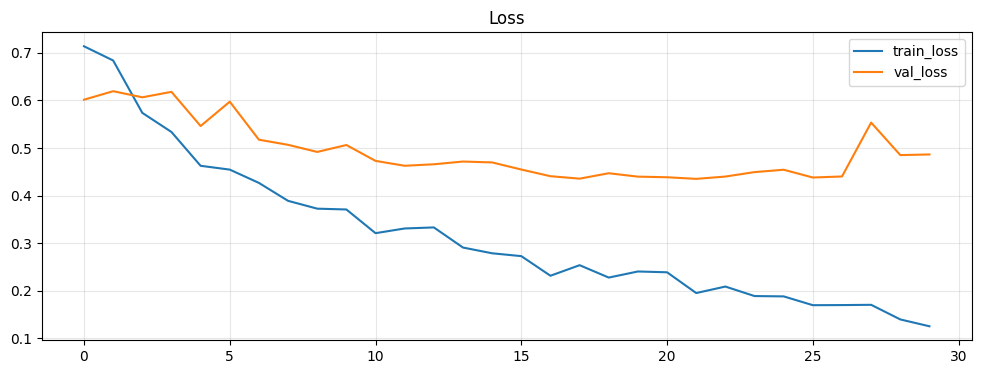

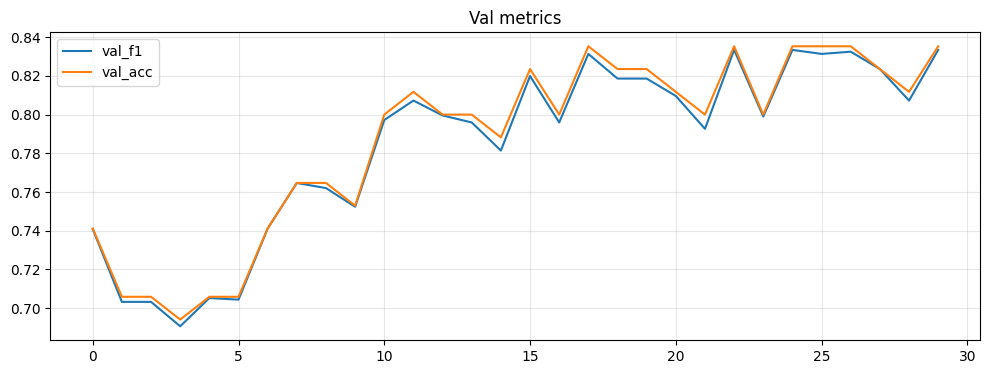

In [132]:
# --- CELDA 11: ENTRENAMIENTO ---
criterion = nn.CrossEntropyLoss()
LR = 1e-4   # suele ir bien
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {"train_loss":[], "val_loss":[], "val_f1":[], "val_acc":[]}
best_f1 = -1.0
best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}

for epoch in range(1, EPOCHS+1):
    model.train()
    tr_loss = 0.0

    for imgs, mask, tab, y in train_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        mask = mask.to(DEVICE, non_blocking=True)
        tab  = tab.to(DEVICE, non_blocking=True)
        y    = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        out = model(imgs, mask, tab)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        tr_loss += loss.item()

    tr_loss /= max(1, len(train_loader))

    model.eval()
    va_loss = 0.0
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, mask, tab, y in val_loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            mask = mask.to(DEVICE, non_blocking=True)
            tab  = tab.to(DEVICE, non_blocking=True)
            y    = y.to(DEVICE, non_blocking=True)

            out = model(imgs, mask, tab)
            loss = criterion(out, y)
            va_loss += loss.item()

            pred = out.argmax(dim=1)
            y_true.extend(y.cpu().numpy().tolist())
            y_pred.extend(pred.cpu().numpy().tolist())

    va_loss /= max(1, len(val_loader))
    va_f1 = f1_score(y_true, y_pred, average="macro")
    va_acc = accuracy_score(y_true, y_pred)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["val_f1"].append(va_f1)
    history["val_acc"].append(va_acc)



    improved = va_f1 > best_f1
    if improved:
        best_f1 = va_f1
        best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}

    print(f"Ep {epoch:02d}/{EPOCHS} | Tloss {tr_loss:.4f} | Vloss {va_loss:.4f} | F1 {va_f1:.4f} | Acc {va_acc:.4f}" + ("  🏆" if improved else ""))

model.load_state_dict({k:v.to(DEVICE) for k,v in best_state.items()})
print("\n🏁 Mejor loss val:", best_f1)

plt.figure(figsize=(12,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend(); plt.grid(True, alpha=0.3); plt.title("Loss"); plt.show()

plt.figure(figsize=(12,4))
plt.plot(history["val_f1"], label="val_f1")
plt.plot(history["val_acc"], label="val_acc")
plt.legend(); plt.grid(True, alpha=0.3); plt.title("Val metrics"); plt.show()


## Cargar pesos del modelo (state_dict o checkpoint)

Esta celda carga unos pesos guardados en disco y reconstruye el modelo para dejarlo listo en modo inferencia.

**Qué hace (idea + implementación):**
- Define la ruta `RUTA_PESOS` y carga el objeto con `torch.load(..., map_location=DEVICE)`.
- Distingue dos formatos posibles:
  - **Checkpoint**: diccionario con clave `"model_state"` → extrae `state_dict = obj["model_state"]`.
  - **State dict**: el propio objeto ya es el `state_dict`.
- Reconstruye el modelo con **la misma arquitectura/args** (`MultiModalAttentionNet5(...)`) y lo mueve a `DEVICE`.
- Carga los pesos con `model.load_state_dict(state_dict, strict=True)` para asegurar coincidencia exacta de claves.
- Imprime claves faltantes o inesperadas (para diagnosticar incompatibilidades) y deja el modelo en `eval()` para inferencia.


In [133]:
import torch
import torch.nn as nn

RUTA_PESOS = "/content/model_best_weights_20260129_095018.pt"

# 0) Carga el archivo
obj = torch.load(RUTA_PESOS, map_location=DEVICE)

# 1) Decide si es checkpoint o state_dict
if isinstance(obj, dict) and "model_state" in obj:
    state_dict = obj["model_state"]
    print("📦 Detectado CHECKPOINT (model_state).")
else:
    state_dict = obj
    print("📦 Detectado STATE_DICT (solo pesos).")

# 2) RECONSTRUIR el modelo EXACTO (pon aquí TU constructor real)
model = MultiModalAttentionNet5(
    tab_dim=TAB_DIM,
    num_classes=NUM_CLASSES,
    path_resnet=PATH_RESNET,
    path_densenet=PATH_DENSENET,
    path_yolo=PATH_YOLO,
    inner_dim=128
).to(DEVICE)

# 3) Cargar pesos SIN reasignar model
incompat = model.load_state_dict(state_dict, strict=True)

print("✅ Pesos cargados.")
print("Missing keys:", incompat.missing_keys)
print("Unexpected keys:", incompat.unexpected_keys)

model.eval()


📦 Detectado STATE_DICT (solo pesos).
[DEBUG] Channels -> ResNet:512 DenseNet:1024 YOLO:768


RuntimeError: Error(s) in loading state_dict for MultiModalAttentionNet5:
	size mismatch for yolo.model.10.linear.weight: copying a param with shape torch.Size([6, 1280]) from checkpoint, the shape in current model is torch.Size([2, 1280]).
	size mismatch for yolo.model.10.linear.bias: copying a param with shape torch.Size([6]) from checkpoint, the shape in current model is torch.Size([2]).
	size mismatch for classifier.8.weight: copying a param with shape torch.Size([6, 128]) from checkpoint, the shape in current model is torch.Size([2, 128]).
	size mismatch for classifier.8.bias: copying a param with shape torch.Size([6]) from checkpoint, the shape in current model is torch.Size([2]).

## Evaluación final en test (multiclase)

Evalúa el modelo entrenado sobre el conjunto de test y reporta métricas y errores por clase usando nombres de clases.

**Qué hace (idea + implementación):**
- Define `class_names` (mapeo índice→nombre) y pone el modelo en `eval()`.
- Recorre `test_loader` sin gradiente (`torch.no_grad()`):
  - hace `out = model(imgs, mask, tab)` (logits)
  - obtiene `pred = argmax(out)` y acumula `y_true`, `y_pred`.
- Calcula métricas globales:
  - `Accuracy`, `Kappa` y `F1-macro`.
- Imprime `classification_report` con `target_names=class_names` para precisión/recall/F1 por clase.
- Construye la **matriz de confusión** y la dibuja con `sns.heatmap` para visualizar qué clases se confunden entre sí.


In [ ]:
# --- CELDA 12: EVALUACIÓN FINAL (MULTICLASE con nombres) ---

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, cohen_kappa_score, f1_score

# Nombres de clase por índice
class_names = ["ACK", "BCC", "MEL", "NEV", "SCC", "SEK"]
#class_names =['benigno','maligno']
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, mask, tab, y in test_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        mask = mask.to(DEVICE, non_blocking=True)
        tab  = tab.to(DEVICE, non_blocking=True)
        y    = y.to(DEVICE, non_blocking=True)

        out = model(imgs, mask, tab)
        pred = out.argmax(dim=1)

        y_true.extend(y.cpu().numpy().tolist())
        y_pred.extend(pred.cpu().numpy().tolist())

acc = accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
f1m = f1_score(y_true, y_pred, average="macro")

print("="*60)
print("TEST RESULTS (MULTICLASE)")
print("="*60)
print(f"Accuracy: {acc:.4f}")
print(f"Kappa   : {kappa:.4f}")
print(f"F1-macro: {f1m:.4f}")
print("-"*60)

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusión - Attention Fusion (Multiclase)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


## Guardar modelo

In [ ]:
# --- CELDA: GUARDAR MODELO / CHECKPOINT (COLAB) ---
import os
import torch
from datetime import datetime

SAVE_DIR = "/content/models"
os.makedirs(SAVE_DIR, exist_ok=True)

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1) Guardar SOLO pesos (lo más común para luego cargar en inferencia)
weights_path = os.path.join(SAVE_DIR, f"model_best_weights_binario2_{run_id}.pt")
torch.save(model.state_dict(), weights_path)
print("✅ Guardado (solo pesos):", weights_path)

# 2) Guardar CHECKPOINT completo (para reanudar entrenamiento)
#    Nota: esto asume que tienes optimizer, scheduler, history, best_f1, epoch definidos.
ckpt_path = os.path.join(SAVE_DIR, f"model_checkpoint_binario2_{run_id}.pt")
checkpoint = {
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict() if "optimizer" in globals() else None,
    "scheduler_state": scheduler.state_dict() if "scheduler" in globals() else None,
    "history": history if "history" in globals() else None,
    "best_f1": best_f1 if "best_f1" in globals() else None,
    "epoch": epoch if "epoch" in globals() else None,
    # Si necesitas recrear arquitectura, guarda también hiperparámetros/args aquí
}
torch.save(checkpoint, ckpt_path)
print("✅ Guardado (checkpoint):", ckpt_path)

# (Opcional) Descargar al PC desde Colab
from google.colab import files
files.download(weights_path)
files.download(ckpt_path)
